In [1]:
import pandas as pd

df = pd.read_csv("diamonds.csv")
print(df.head())
print(df.info())
print(df.describe())

   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  

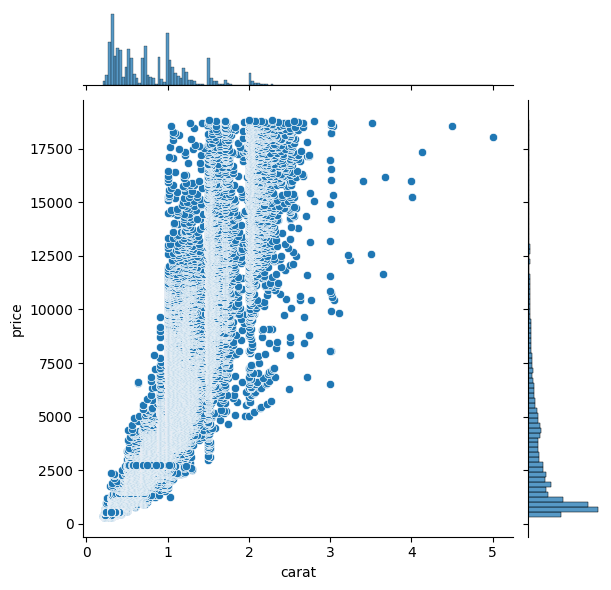

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(data=df, x="carat", y="price", kind="scatter")
plt.show()

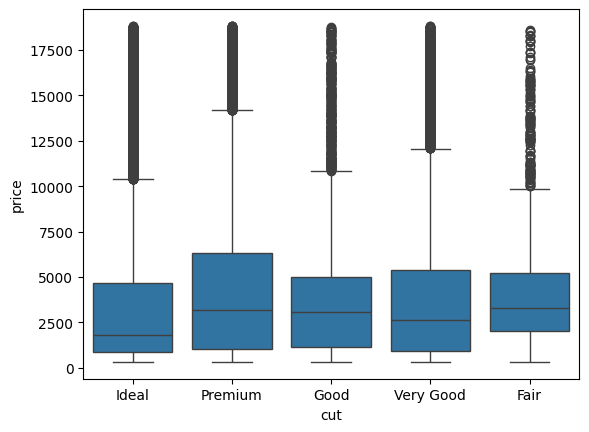

In [3]:
sns.boxplot(x="cut", y="price", data=df)
plt.show()

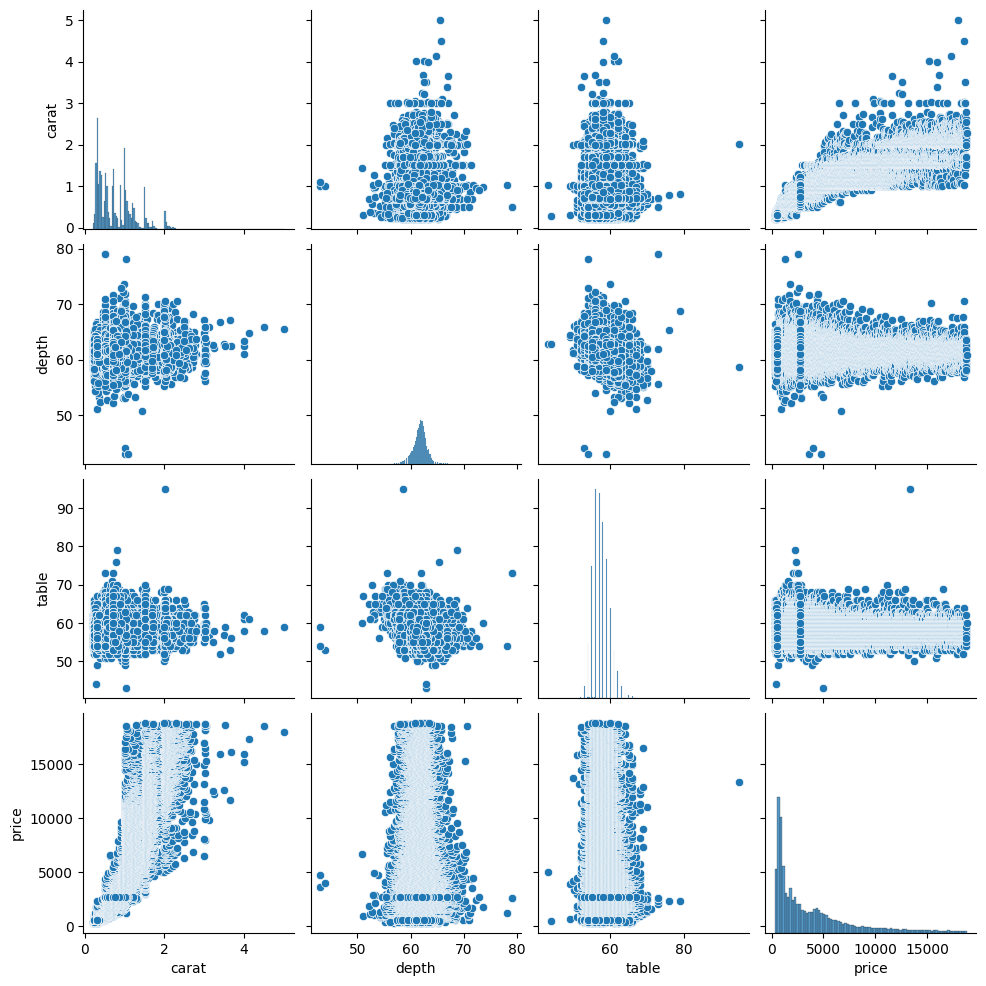

In [4]:
sns.pairplot(df[["carat", "depth", "table", "price"]])
plt.show()

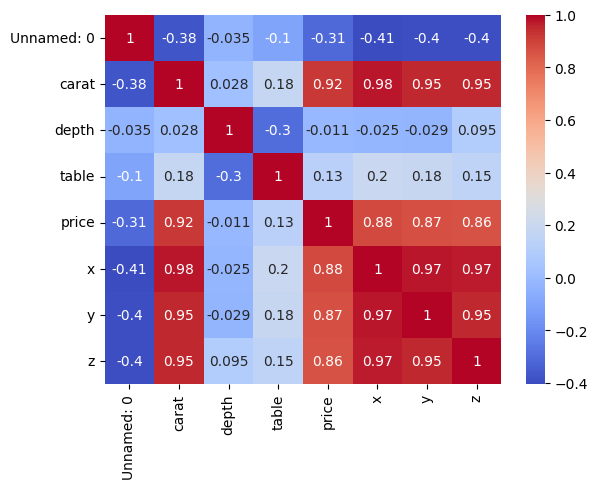

In [5]:
import numpy as np

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [6]:
df = pd.get_dummies(df, drop_first=True)

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNet, BayesianRidge
from sklearn.metrics import mean_squared_error

scaler = MinMaxScaler()

X = df.drop("price", axis=1)
y = df["price"]

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)

ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=5)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("Best alpha (Ridge):", ridge.alpha_) #hiper parametar (stepenot na regularizacija se kontrolira so alpha)

lasso = LassoCV(alphas=None, cv=5, max_iter=10000)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print("Best alpha (Lasso):", lasso.alpha_)

elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)

bayesian = BayesianRidge()
bayesian.fit(X_train, y_train)

y_pred_bayes = bayesian.predict(X_test)
mse_bayes = mean_squared_error(y_test, y_pred_bayes)

print("MSE Results:")
print("Linear Regression:", mse_lr)
print("Ridge:", mse_ridge)
print("Lasso:", mse_lasso)
print("ElasticNet:", mse_elastic)
print("Bayesian Ridge:", mse_bayes)

Best alpha (Ridge): 0.1


C:\Users\nasto\PycharmProjects\MU_examples\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


Best alpha (Lasso): 0.36798024590446127
MSE Results:
Linear Regression: 1282237.940981841
Ridge: 1282116.3604996921
Lasso: 1283030.814218055
ElasticNet: 14219177.796022847
Bayesian Ridge: 1282222.010125242
